In [4]:
!pip install pandas numpy

In [58]:
import pandas as pd
import numpy as np

In [60]:
df=pd.read_csv(r"C:\Users\shaiv\Downloads\data analytics projects\bayesian_ab_testing_platform\data\processed/base_customer_behavior_dataset.csv")

In [61]:
np.random.seed(42)

In [62]:
customer_variants = df[
    ["customer_unique_id"]
].drop_duplicates()

In [66]:
customer_variants["variant"] = np.random.choice(
    ["A", "B"],
    size=len(customer_variants),
    p=[0.7, 0.3]
)

In [68]:
df = df.merge(
    customer_variants,
    on="customer_unique_id",
    how="left"
)

In [70]:
#verify distribution
df["variant"].value_counts(normalize=True)

variant
A    0.701086
B    0.298914
Name: proportion, dtype: float64

In [118]:
df["device_type"]=np.random.choice(
    ["Mobile","Desktop","Tablet"],
    size=len(df),
    p=[0.70,0.25,0.05]
)

In [120]:
df["device_type"].value_counts(normalize=True)

device_type
Mobile     0.700386
Desktop    0.249990
Tablet     0.049624
Name: proportion, dtype: float64

In [72]:
#default conversion probability for each customer
df["base_conversion_prob"]=0.05

In [74]:
df.loc[df["customer_segment"]=="High Value",
"base_conversion_prob"]+=0.05

In [76]:
df.loc[df["customer_segment"]=="Medium Value",
"base_conversion_prob"]+=0.02

In [78]:
df.loc[df["customer_segment"]=="Low Value",
"base_conversion_prob"]-=0.01

In [80]:
df.loc[df["payment_retry_flag"]==1,
"base_conversion_prob"
]-=0.02

In [82]:
df["delivery_delay_days"].describe()

count    97005.000000
mean       -11.880790
std         10.183992
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64

<Axes: >

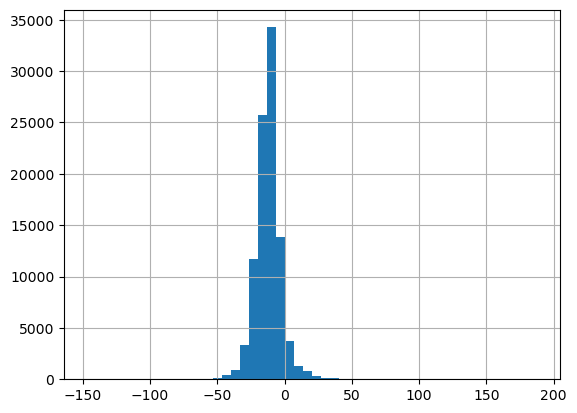

In [84]:
df["delivery_delay_days"].hist(bins=50)

In [86]:
#mild penalty for one week delayed delivery
df.loc[
    (df["delivery_delay_days"] > 0) &
    (df["delivery_delay_days"] <= 7),
    "base_conversion_prob"
] -= 0.01

In [88]:
#moderate penalty for 7<Days<=20 days delayed delivery
df.loc[
    (df["delivery_delay_days"] > 7) &
    (df["delivery_delay_days"] <= 20),
    "base_conversion_prob"
] -= 0.03

In [90]:
#severe penalty for more than 20 days delayed delivery
df.loc[
    df["delivery_delay_days"] > 20,
    "base_conversion_prob"
] -= 0.06

In [92]:
df.loc[df["variant"]=="B",
"base_conversion_prob"]+=0.03

In [122]:
df.loc[
    df["device_type"] == "Desktop",
    "base_conversion_prob"
] += 0.005

df.loc[
    df["device_type"] == "Mobile",
    "base_conversion_prob"
] -= 0.003

In [124]:
df["base_conversion_prob"]=df["base_conversion_prob"].clip(0,1)

In [126]:
df["converted"] = np.random.binomial(
    1,
    df["base_conversion_prob"]
)

In [128]:
df.groupby("variant")["converted"].mean()

variant
A    0.066146
B    0.098063
Name: converted, dtype: float64

In [130]:
df["base_click_prob"] = 0.10

df.loc[
    df["customer_segment"] == "High Value",
    "base_click_prob"
] += 0.05

df.loc[
    df["customer_segment"] == "Medium Value",
    "base_click_prob"
] += 0.02

df.loc[
    df["customer_segment"] == "Low Value",
    "base_click_prob"
] -= 0.01

df.loc[
    df["variant"] == "B",
    "base_click_prob"
] += 0.03

df.loc[
    df["payment_retry_flag"] == 1,
    "base_click_prob"
] -= 0.005

df.loc[
    df["delivery_delay_days"] > 20,
    "base_click_prob"
] -= 0.01

df.loc[
    df["device_type"] == "Mobile",
    "base_click_prob"
] += 0.005

df.loc[
    df["device_type"] == "Desktop",
    "base_click_prob"
] -= 0.003

In [132]:
df["base_click_prob"]=df["base_click_prob"].clip(0,1)

In [134]:
df["clicked"]=np.random.binomial(
    1,
    df["base_click_prob"]
)

In [136]:
df.groupby("variant")["clicked"].mean()

variant
A    0.123076
B    0.150490
Name: clicked, dtype: float64

In [138]:
#revenue uplift
df["experiment_revenue"]=df["payment_value"]

In [140]:
df.loc[df["variant"]=="B",
"experiment_revenue"]*=np.random.uniform(
    1.03,1.08,size=(df["variant"]=="B").sum()
)

In [142]:
df.groupby("variant")["experiment_revenue"].mean()

variant
A    160.973982
B    169.310914
Name: experiment_revenue, dtype: float64

In [144]:
df.to_csv(
    r"C:\Users\shaiv\Downloads\data analytics projects\bayesian_ab_testing_platform\data\experiments/ab_experiment_dataset.csv",
    index=False
)